In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

import pandas as pd
import numpy as np
import os
import cv2
from PIL import Image
from keras.preprocessing.image import load_img


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import cv2
from PIL import Image
from keras.preprocessing.image import load_img

import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, Input
from tensorflow.keras.utils import plot_model

from pathlib import Path

from sklearn.model_selection import train_test_split
from tqdm import tqdm

from tensorflow.keras.initializers import (
    random_uniform,
    glorot_uniform,
    constant,
    identity
)

from tensorflow.keras.layers import (
    Add,
    BatchNormalization,
    GlobalMaxPooling2D
)

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping
)

from tensorflow.keras import datasets, layers, models

In [ ]:
BASE_DIRS=[r'/kaggle/input/datasets/jangedoo/utkface-new/UTKFace']


In [ ]:
import os
image_paths=[]
age_labels=[]
gender_labels=[]
for BASE_DIR in BASE_DIRS:
    for filename in tqdm(os.listdir(BASE_DIR)):
        temp = filename.split('_')

        if temp[0].isdigit():
            age = int(temp[0])
            gender = int(temp[1])

            image_path = os.path.join(BASE_DIR, filename)
        image_paths.append(image_path)
        age_labels.append(age)
        gender_labels.append(gender)
    

In [ ]:
df=pd.DataFrame();
df['Image'],df['Age'],df['gender']=image_paths,age_labels,gender_labels
df.head(5)

In [ ]:
print(f"Dataframe:{df}")
print(f"dateframe size:{df.shape}")


In [ ]:
gender_dict={0:'male',1:
            "female"}

In [ ]:
if not df.empty:
    try:
        img = Image.open(df['Image'][0])
        plt.axis('off')
        plt.imshow(img)
        plt.show()
    except Exception as e:
        print(f"Error opening image: {e}")
else:
    print(f"Dataframe is empty, no images found.")

In [ ]:
import seaborn as sns
sns.distplot(df["Age"],kde="true",bins=30)

plt.title("age distribution")
plt.xlabel("age")
plt.ylabel("frequency")

In [ ]:
def extract_feature(images):
    features = []

    for image in tqdm(images):
        img = Image.open(image).convert('L')
        img = img.resize((128, 128), Image.BILINEAR)
        img = np.array(img)

        features.append(img)

    features = np.array(features)
    features = features.reshape(len(features), 128, 128, 1)

    return features

In [ ]:
x=extract_feature(df['Image'])
print(f"X_shape:\t{x.shape}")

In [ ]:
x = x / 255.0

y_gender = np.array(df['gender'])
y_age = np.array(df['Age'])

print("shape of y_gender:", y_gender.shape)
print("shape of y_age:", y_age.shape)

In [ ]:
input_shape = (128,128,1)
inputs = Input(input_shape)

conv1 = Conv2D(32,kernel_size=(3,3),activation='relu')(inputs)
maxp1 = MaxPooling2D(pool_size=(2,2))(conv1)

conv2 = Conv2D(64,kernel_size=(3,3),activation='relu')(maxp1)
maxp2 = MaxPooling2D(pool_size=(2,2))(conv2)

conv3 = Conv2D(128,kernel_size=(3,3),activation='relu')(maxp2)
maxp3 = MaxPooling2D(pool_size=(2,2))(conv3)

conv4 = Conv2D(256,kernel_size=(3,3),activation='relu')(maxp3)
maxp4 = MaxPooling2D(pool_size=(2,2))(conv4)

flatten = Flatten()(maxp4)

dense1 = Dense(256,activation='relu')(flatten)
dense2 = Dense(256,activation='relu')(flatten)

dropout1 = Dropout(0.3)(dense1)
dropout2 = Dropout(0.3)(dense2)

output1 = Dense(1,activation='sigmoid',name='gender_out')(dropout1)
output2 = Dense(1,activation='relu',name='age_out')(dropout2)

model = Model(inputs=inputs,outputs=[output1,output2])

model.summary()

In [ ]:
y_combined = np.column_stack((y_age, y_gender))

X_train, X_temp, y_combined_train, y_combined_temp = train_test_split(
    x, y_combined,
    test_size=0.2,
    random_state=42
)

X_test, X_val, y_combined_test, y_combined_val = train_test_split(
    X_temp, y_combined_temp,
    test_size=0.5,
    random_state=42
)

In [ ]:
y_train_age, y_train_gender = y_combined_train[:,0], y_combined_train[:,1]

y_test_age, y_test_gender = y_combined_test[:,0], y_combined_test[:,1]

y_val_age, y_val_gender = y_combined_val[:,0], y_combined_val[:,1]

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint
model_path = './best_model.keras'

checkpoint = ModelCheckpoint(
    filepath=model_path,
    monitor='val_gender_out_accuracy',
    verbose=1,
    mode='max',
    save_best_only=True
)

In [ ]:
from keras.callbacks import LearningRateScheduler

model.compile(
    loss=['binary_crossentropy', 'mae'],
    optimizer='adam',
    metrics=['accuracy', 'mae']
)

annealer = LearningRateScheduler(
    lambda x: 1e-3 * 0.9 ** x
)

In [ ]:
total_images=len(image_paths)
print(f"total number of images :{total_images}s")

In [ ]:
train_images=len(X_train)
validation_images=len(X_val)
test_images=len(X_test)
print(f"number of training images: {train_images}")
print(f"number of validation images: {validation_images}")
print(f"number of test images:{test_images}")


In [ ]:
import tensorflow as tf

tf.config.run_functions_eagerly(True)

history = model.fit(
    x=X_train,
    y=[y_train_gender, y_train_age],
    batch_size=128,
    epochs=30,
    validation_data=(X_val, [y_val_gender, y_val_age]),
    callbacks=[checkpoint]
)

In [ ]:
acc = history.history['gender_out_accuracy']
val_acc = history.history['val_gender_out_accuracy']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')

plt.title('Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
plt.plot(history.history['age_out_mae'])
plt.plot(history.history['val_age_out_mae'])

plt.title('Age Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

In [ ]:
image_index = 3000

print(
    f"Original Gender: {gender_dict[y_gender[image_index]]}\t"
    f"Original Age: {y_age[image_index]}"
)

pred = model.predict(
    x[image_index].reshape(1, 128, 128, 1)
)

pred_gender = gender_dict[int(round(pred[0][0][0]))]
pred_age = round(pred[1][0][0])

print(
    f"Predicted Gender: {pred_gender}\t"
    f"Predicted Age: {pred_age}"
)

In [ ]:
from IPython.display import FileLink

FileLink('/kaggle/working/best_model.keras')

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

UTK_DIR = '/kaggle/input/datasets/jangedoo/utkface-new/UTKFace'

# Filter young males (20-30)
young_males   = []
young_females = []

for f in os.listdir(UTK_DIR):
    try:
        parts  = f.split('_')
        age    = int(parts[0])
        gender = int(parts[1])
        if 20 <= age <= 30:
            if gender == 0:
                young_males.append(f)
            else:
                young_females.append(f)
    except:
        continue

print(f"Young males (20-30)  : {len(young_males)}")
print(f"Young females (20-30): {len(young_females)}")

# Show 16 young males
samples = random.sample(young_males, min(16, len(young_males)))
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for ax, img_file in zip(axes.flatten(), samples):
    img = Image.open(os.path.join(UTK_DIR, img_file))
    ax.imshow(img)
    ax.set_title(f"M {img_file.split('_')[0]}y", fontsize=8)
    ax.axis('off')
plt.suptitle('Young MALES (20-30) in UTKFace — any long hair?', fontsize=13)
plt.tight_layout()
plt.show()

# Show 16 young females
samples = random.sample(young_females, min(16, len(young_females)))
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for ax, img_file in zip(axes.flatten(), samples):
    img = Image.open(os.path.join(UTK_DIR, img_file))
    ax.imshow(img)
    ax.set_title(f"F {img_file.split('_')[0]}y", fontsize=8)
    ax.axis('off')
plt.suptitle('Young FEMALES (20-30) in UTKFace — any short hair?', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
import os
import shutil
import random
import pandas as pd

UTK_DIR = '/kaggle/input/datasets/jangedoo/utkface-new/UTKFace'

# Get ALL young people (20-30)
young_males   = []
young_females = []

for f in os.listdir(UTK_DIR):
    try:
        parts  = f.split('_')
        age    = int(parts[0])
        gender = int(parts[1])
        if 20 <= age <= 30:
            if gender == 0:
                young_males.append(f)
            else:
                young_females.append(f)
    except:
        continue

print(f"Young males   : {len(young_males)}")
print(f"Young females : {len(young_females)}")

# Sample 250 of each
random.seed(42)
sample_males   = random.sample(young_males,   min(250, len(young_males)))
sample_females = random.sample(young_females, min(250, len(young_females)))

# Save to output
OUTPUT = '/kaggle/working/to_label'
os.makedirs(OUTPUT, exist_ok=True)

for f in sample_males + sample_females:
    shutil.copy(os.path.join(UTK_DIR, f),
                os.path.join(OUTPUT, f))

print(f"\n✓ Saved {len(sample_males) + len(sample_females)} images")

# Zip for download
shutil.make_archive('/kaggle/working/to_label', 'zip', OUTPUT)
print("✓ to_label.zip ready — download from output panel!")

In [ ]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.csv'):
            print(os.path.join(root, f))

In [ ]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/tanishsam/hair-dataset/hair_labels.csv')

print(f"Total labeled: {len(df)}")
print(df['hair_length'].value_counts())
print(df.head())

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ── Paths ──────────────────────────────────────────────────
UTK_DIR  = '/kaggle/input/datasets/jangedoo/utkface-new/UTKFace'
CSV_PATH = '/kaggle/input/datasets/tanishsam/hair-dataset/hair_labels.csv'

# ── Load manual labels ─────────────────────────────────────
manual_df = pd.read_csv(CSV_PATH)
manual_df = manual_df[manual_df['hair_length'] != 'skip'].copy()
manual_df = manual_df.reset_index(drop=True)

# Fix image paths to Kaggle UTKFace
manual_df['img_path'] = manual_df['filename'].apply(
    lambda x: os.path.join(UTK_DIR, x)
)

print(f"Manual labels (after skip removal): {len(manual_df)}")
print(manual_df['hair_length'].value_counts())

In [ ]:
# ── Auto label outside 20-30 from UTKFace ─────────────────
auto_labels = []

for f in os.listdir(UTK_DIR):
    try:
        parts  = f.split('_')
        age    = int(parts[0])
        gender = int(parts[1])

        # Only auto label OUTSIDE 20-30
        if age < 20 or age > 30:
            auto_labels.append({
                'filename'   : f,
                'img_path'   : os.path.join(UTK_DIR, f),
                'hair_length': 'long' if gender == 1 else 'short'
            })
    except:
        continue

auto_df = pd.DataFrame(auto_labels)
print(f"Auto labeled (outside 20-30): {len(auto_df)}")
print(auto_df['hair_length'].value_counts())

# ── Combine manual + auto ──────────────────────────────────
full_df = pd.concat([manual_df, auto_df]).reset_index(drop=True)
print(f"\nTotal combined: {len(full_df)}")
print(full_df['hair_length'].value_counts())

In [ ]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

UTK_DIR  = '/kaggle/input/datasets/jangedoo/utkface-new/UTKFace'
CSV_PATH = '/kaggle/input/datasets/tanishsam/hair-dataset/hair_labels.csv'

# Load only your manual labels
df = pd.read_csv(CSV_PATH)
df = df[df['hair_length'] != 'skip'].copy()
df['img_path'] = df['filename'].apply(lambda x: os.path.join(UTK_DIR, x))
df['label']    = df['hair_length'].apply(lambda x: 1 if x == 'long' else 0)

print(f"Total: {len(df)}")
print(df['hair_length'].value_counts())

# Split 80/10/10
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df,  test_df  = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Dataset
class HairDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['img_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(row['label'], dtype=torch.long)

# Transforms — augment heavily since only 405 images
train_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomRotation(10),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.2),
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_ds = HairDataset(train_df, train_transform)
val_ds   = HairDataset(val_df,   val_transform)
test_ds  = HairDataset(test_df,  val_transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=2)

print(f"\nTrain batches: {len(train_loader)}")

# Model — ResNet18 (better than MobileNet for small datasets)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

from torchvision.models import ResNet18_Weights
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

# Training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0, 0, 0
    ctx  = torch.enable_grad() if training else torch.no_grad()
    pbar = tqdm(loader, desc="Train" if training else "Val  ", leave=False)
    with ctx:
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            if training: optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            correct    += (out.argmax(1) == labels).sum().item()
            total      += labels.size(0)
            pbar.set_postfix({'loss': f'{total_loss/(pbar.n+1):.3f}',
                              'acc' : f'{correct/total:.3f}'})
    return total_loss/len(loader), correct/total

EPOCHS = 15  # more epochs since small dataset
print("="*50)
print(f"Training hair model on {len(train_df)} UTKFace images")
print("="*50)

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)
    scheduler.step()
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"Train loss:{tr_loss:.3f} acc:{tr_acc:.3f} | "
          f"Val loss:{vl_loss:.3f} acc:{vl_acc:.3f}")

torch.save(model.state_dict(), 'hair_model_utk.pth')
print("\n✓ Saved as hair_model_utk.pth")

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, EPOCHS+1)

axes[0].plot(epochs, history['train_loss'], 'o-', color='#E8593C', label='Train')
axes[0].plot(epochs, history['val_loss'],   'o-', color='#3B8BD4', label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['train_acc'], 'o-', color='#E8593C', label='Train')
axes[1].plot(epochs, history['val_acc'],   'o-', color='#3B8BD4', label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Test set evaluation
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds,
      target_names=['Short hair', 'Long hair']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Short', 'Long'],
            yticklabels=['Short', 'Long'], ax=ax)
ax.set_title('Confusion Matrix — UTKFace Hair Model')
plt.tight_layout()
plt.show()

In [ ]:
# Save final model
torch.save(model.state_dict(), '/kaggle/working/hair_model_utk.pth')
print("✓ Download hair_model_utk.pth from output panel!")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load labels
df = pd.read_csv('/kaggle/input/datasets/tanishsam/hair-dataset/hair_labels.csv')
df = df[df['hair_length'] != 'skip']

hair_counts = df['hair_length'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Hair Label Distribution', fontsize=15, fontweight='bold')

# Bar chart
colors = ['#E8593C', '#3B8BD4']
bars = axes[0].bar(hair_counts.index, hair_counts.values,
                   color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Hair Length Count', fontsize=13)
axes[0].set_xlabel('Hair Length')
axes[0].set_ylabel('Count')
for bar, v in zip(bars, hair_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 v + 2, str(v), ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(hair_counts.values) + 20)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(
    hair_counts.values,
    labels=[f'Long Hair\n({hair_counts["long"]})',
            f'Short Hair\n({hair_counts["short"]})'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)
axes[1].set_title('Hair Length Proportion', fontsize=13)

plt.tight_layout()
plt.savefig('/kaggle/working/hair_label_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved as hair_label_distribution.png")

In [3]:
import pandas as pd
import numpy as np
import os
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tqdm
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Conv2D, Dropout, Flatten, MaxPooling2D, Input
)
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.model_selection import train_test_split
from tqdm import tqdm

print("TF version:", tf.__version__)

2026-06-24 17:54:35.384782: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782323675.821793      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782323675.945767      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782323676.904600      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782323676.904659      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782323676.904663      58 computation_placer.cc:177] computation placer alr

TF version: 2.19.0


In [4]:
BASE_DIR = '/kaggle/input/datasets/jangedoo/utkface-new/UTKFace'

image_paths  = []
age_labels   = []
gender_labels = []

for filename in tqdm(os.listdir(BASE_DIR)):
    temp = filename.split('_')
    if temp[0].isdigit():
        age    = int(temp[0])
        gender = int(temp[1])
        image_paths.append(os.path.join(BASE_DIR, filename))
        age_labels.append(age)
        gender_labels.append(gender)

df = pd.DataFrame()
df['Image']  = image_paths
df['Age']    = age_labels
df['gender'] = gender_labels

print(f"Total images: {len(df)}")
print(df.head())

100%|██████████| 23708/23708 [00:00<00:00, 434620.48it/s]

Total images: 23708
                                               Image  Age  gender
0  /kaggle/input/datasets/jangedoo/utkface-new/UT...   26       0
1  /kaggle/input/datasets/jangedoo/utkface-new/UT...   22       1
2  /kaggle/input/datasets/jangedoo/utkface-new/UT...   21       1
3  /kaggle/input/datasets/jangedoo/utkface-new/UT...   28       0
4  /kaggle/input/datasets/jangedoo/utkface-new/UT...   17       1


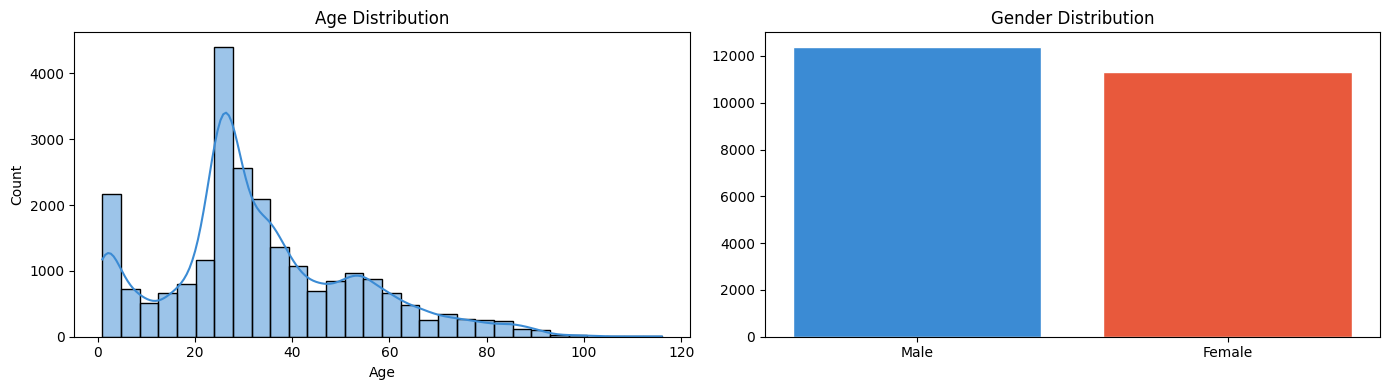

In [5]:
gender_dict = {0: 'male', 1: 'female'}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Age distribution
sns.histplot(df["Age"], kde=True, bins=30, ax=axes[0], color='#3B8BD4')
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

# Gender distribution
gender_counts = df['gender'].value_counts()
axes[1].bar(['Male', 'Female'], gender_counts.values,
            color=['#3B8BD4', '#E8593C'], edgecolor='white')
axes[1].set_title("Gender Distribution")

plt.tight_layout()
plt.show()

In [6]:
def extract_feature(images):
    features = []
    for image in tqdm(images):
        img = Image.open(image).convert('L')
        img = img.resize((128, 128), Image.BILINEAR)
        img = np.array(img)
        features.append(img)
    features = np.array(features)
    features = features.reshape(len(features), 128, 128, 1)
    return features

x = extract_feature(df['Image'])
print(f"X shape: {x.shape}")

100%|██████████| 23708/23708 [03:06<00:00, 127.29it/s]


X shape: (23708, 128, 128, 1)


In [7]:
x = x / 255.0

y_gender = np.array(df['gender'])
y_age    = np.array(df['Age'])

print("y_gender shape:", y_gender.shape)
print("y_age shape:", y_age.shape)

y_gender shape: (23708,)
y_age shape: (23708,)


In [8]:
input_shape = (128, 128, 1)
inputs = Input(input_shape)

conv1 = Conv2D(32,  kernel_size=(3,3), activation='relu')(inputs)
maxp1 = MaxPooling2D(pool_size=(2,2))(conv1)

conv2 = Conv2D(64,  kernel_size=(3,3), activation='relu')(maxp1)
maxp2 = MaxPooling2D(pool_size=(2,2))(conv2)

conv3 = Conv2D(128, kernel_size=(3,3), activation='relu')(maxp2)
maxp3 = MaxPooling2D(pool_size=(2,2))(conv3)

conv4 = Conv2D(256, kernel_size=(3,3), activation='relu')(maxp3)
maxp4 = MaxPooling2D(pool_size=(2,2))(conv4)

flatten = Flatten()(maxp4)

dense1 = Dense(256, activation='relu')(flatten)
dense2 = Dense(256, activation='relu')(flatten)

dropout1 = Dropout(0.3)(dense1)
dropout2 = Dropout(0.3)(dense2)

output_gender = Dense(1, activation='sigmoid', name='gender_out')(dropout1)
output_age    = Dense(1, activation='relu',    name='age_out')(dropout2)

model = Model(inputs=inputs, outputs=[output_gender, output_age])
model.summary()

I0000 00:00:1782324297.116590      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782324297.123014      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 126, 126,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 63, 63,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 30, 30,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 12, 12,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 6, 6, 256) │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 9216)      │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  2,359,552 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │  2,359,552 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_out (Dense)  │ (None, 1)         │        257 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_out (Dense)     │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,107,458 (19.48 MB)

 Trainable params: 5,107,458 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
y_combined = np.column_stack((y_age, y_gender))

X_train, X_temp, y_train_c, y_temp_c = train_test_split(
    x, y_combined, test_size=0.2, random_state=42
)
X_test, X_val, y_test_c, y_val_c = train_test_split(
    X_temp, y_temp_c, test_size=0.5, random_state=42
)

y_train_age, y_train_gender = y_train_c[:, 0], y_train_c[:, 1]
y_test_age,  y_test_gender  = y_test_c[:, 0],  y_test_c[:, 1]
y_val_age,   y_val_gender   = y_val_c[:, 0],   y_val_c[:, 1]

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 18966 | Val: 2371 | Test: 2371


In [13]:
# ── Random Erasing ─────────────────────────────────────────────────────
def random_erasing(img, p=0.5, s_min=0.02, s_max=0.2, r_min=0.3, r_max=3.3):
    if np.random.rand() > p:
        return img
    h, w = img.shape[0], img.shape[1]
    area = h * w
    for _ in range(10):
        target_area = np.random.uniform(s_min, s_max) * area
        aspect      = np.random.uniform(r_min, r_max)
        eh = int(round(np.sqrt(target_area * aspect)))
        ew = int(round(np.sqrt(target_area / aspect)))
        if eh < h and ew < w:
            y = np.random.randint(0, h - eh)
            xx = np.random.randint(0, w - ew)
            img[y:y+eh, xx:xx+ew, :] = np.random.rand()
            return img
    return img

# Apply random erasing to entire training set ONCE per epoch via numpy
# (simpler + avoids generator type issues in newer TF)
def augment_batch(X):
    X_aug = X.copy()
    for i in range(len(X_aug)):
        if np.random.rand() > 0.5:           # horizontal flip
            X_aug[i] = X_aug[i][:, ::-1, :]
        X_aug[i] = random_erasing(X_aug[i])  # random erase
    return X_aug

print("✓ Augmentation functions ready")

✓ Augmentation functions ready


In [14]:
model.compile(
    loss=['binary_crossentropy', 'mae'],
    optimizer='adam',
    metrics=['accuracy', 'mae']
)

checkpoint = ModelCheckpoint(
    filepath='./best_model.keras',
    monitor='val_gender_out_accuracy',
    verbose=1,
    mode='max',
    save_best_only=True
)

print("✓ Model compiled")


Epoch 1/30


I0000 00:00:1782324454.543091     169 service.cc:152] XLA service 0x7e74f0015aa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782324454.543147     169 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782324454.543153     169 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782324455.486902     169 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-24 18:07:39.937550: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-24 18:07:40.105038: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  2/149 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - age_out_loss: 32.8227 - age_out_mae: 32.8227 - gender_out_accuracy: 0.5000 - gender_out_loss: 0.6931 - loss: 33.5159 

I0000 00:00:1782324465.326830     169 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


148/149 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - age_out_loss: 18.0348 - age_out_mae: 18.0348 - gender_out_accuracy: 0.5183 - gender_out_loss: 0.7549 - loss: 18.7897

KeyboardInterrupt: 

In [15]:
import time

EPOCHS = 30
best_val_acc = 0

history = {
    'gender_out_accuracy': [],
    'val_gender_out_accuracy': [],
    'age_out_mae': [],
    'val_age_out_mae': []
}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # Apply fresh augmentation to training data each epoch
    X_train_aug = augment_batch(X_train)

    # Train for one epoch
    h = model.fit(
        X_train_aug,
        [y_train_gender, y_train_age],
        batch_size=128,
        epochs=1,
        validation_data=(X_val, [y_val_gender, y_val_age]),
        verbose=1
    )

    # Record history
    history['gender_out_accuracy'].append(h.history['gender_out_accuracy'][0])
    history['val_gender_out_accuracy'].append(h.history['val_gender_out_accuracy'][0])
    history['age_out_mae'].append(h.history['age_out_mae'][0])
    history['val_age_out_mae'].append(h.history['val_age_out_mae'][0])

    # Save best model
    val_acc = h.history['val_gender_out_accuracy'][0]
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save('/kaggle/working/best_model.keras')
        print(f"✓ Saved! Best val gender acc: {val_acc:.4f}")

print(f"\n✓ Training complete! Best val accuracy: {best_val_acc:.4f}")


Epoch 1/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 14s 93ms/step - age_out_loss: 14.1512 - age_out_mae: 14.1411 - gender_out_accuracy: 0.6146 - gender_out_loss: 0.6446 - loss: 14.7861 - val_age_out_loss: 11.8645 - val_age_out_mae: 11.8607 - val_gender_out_accuracy: 0.7296 - val_gender_out_loss: 0.5309 - val_loss: 12.3949
✓ Saved! Best val gender acc: 0.7296

Epoch 2/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - age_out_loss: 12.3420 - age_out_mae: 12.3386 - gender_out_accuracy: 0.7263 - gender_out_loss: 0.5390 - loss: 12.8774 - val_age_out_loss: 10.4613 - val_age_out_mae: 10.4491 - val_gender_out_accuracy: 0.7575 - val_gender_out_loss: 0.4777 - val_loss: 10.9306
✓ Saved! Best val gender acc: 0.7575

Epoch 3/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - age_out_loss: 11.0246 - age_out_mae: 11.0047 - gender_out_accuracy: 0.7581 - gender_out_loss: 0.4896 - loss: 11.4939 - val_age_out_loss: 9.6483 - val_age_out_mae: 9.6230 - val_gender_out_accuracy: 0.7942 - val_gender_out_loss: 0.4294 - val_los

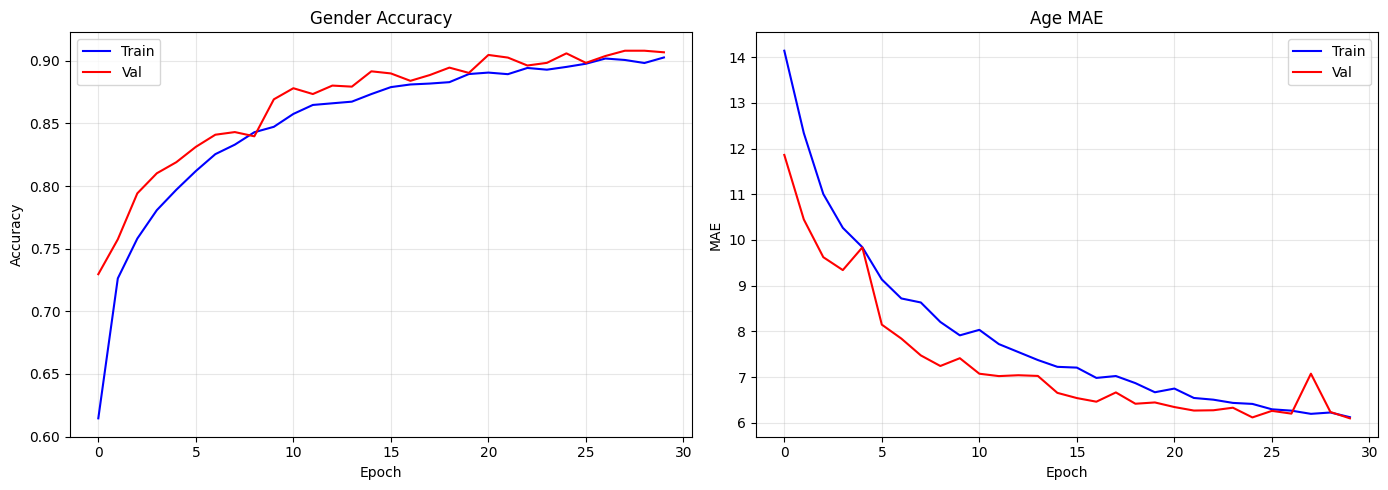

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['gender_out_accuracy'], 'b', label='Train')
axes[0].plot(history['val_gender_out_accuracy'], 'r', label='Val')
axes[0].set_title('Gender Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['age_out_mae'], 'b', label='Train')
axes[1].plot(history['val_age_out_mae'], 'r', label='Val')
axes[1].set_title('Age MAE')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [17]:
# Load the best saved model
best_model = tf.keras.models.load_model('/kaggle/working/best_model.keras')

# Evaluate on test set
results = best_model.evaluate(
    X_test,
    [y_test_gender, y_test_age],
    verbose=1
)

print("\n── Test Results ──")
for name, val in zip(best_model.metrics_names, results):
    print(f"{name}: {val:.4f}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - age_out_loss: 7.2379 - age_out_mae: 7.2131 - gender_out_accuracy: 0.9059 - gender_out_loss: 0.2206 - loss: 7.4345

── Test Results ──
loss: 7.4345
compile_metrics: 0.2206
gender_out_loss: 7.2379
age_out_loss: 7.2131


In [18]:
import random

# Find young males (20-30) — these often have the long hair problem
young_males_idx = [i for i in range(len(df))
                   if df.iloc[i]['gender'] == 0
                   and 20 <= df.iloc[i]['Age'] <= 30]

random.seed(42)
sample_idx = random.sample(young_males_idx, min(50, len(young_males_idx)))

correct_male = 0
for idx in sample_idx:
    pred = best_model.predict(x[idx].reshape(1, 128, 128, 1), verbose=0)
    pred_gender = int(round(pred[0][0][0]))  # 0=male, 1=female
    if pred_gender == 0:
        correct_male += 1

print(f"Young males (20-30) correctly predicted as Male:")
print(f"  {correct_male}/{len(sample_idx)} ({100*correct_male/len(sample_idx):.0f}%)")

# Same for young females
young_females_idx = [i for i in range(len(df))
                     if df.iloc[i]['gender'] == 1
                     and 20 <= df.iloc[i]['Age'] <= 30]
sample_idx_f = random.sample(young_females_idx, min(50, len(young_females_idx)))

correct_female = 0
for idx in sample_idx_f:
    pred = best_model.predict(x[idx].reshape(1, 128, 128, 1), verbose=0)
    pred_gender = int(round(pred[0][0][0]))
    if pred_gender == 1:
        correct_female += 1

print(f"\nYoung females (20-30) correctly predicted as Female:")
print(f"  {correct_female}/{len(sample_idx_f)} ({100*correct_female/len(sample_idx_f):.0f}%)")

Young males (20-30) correctly predicted as Male:
  48/50 (96%)

Young females (20-30) correctly predicted as Female:
  49/50 (98%)


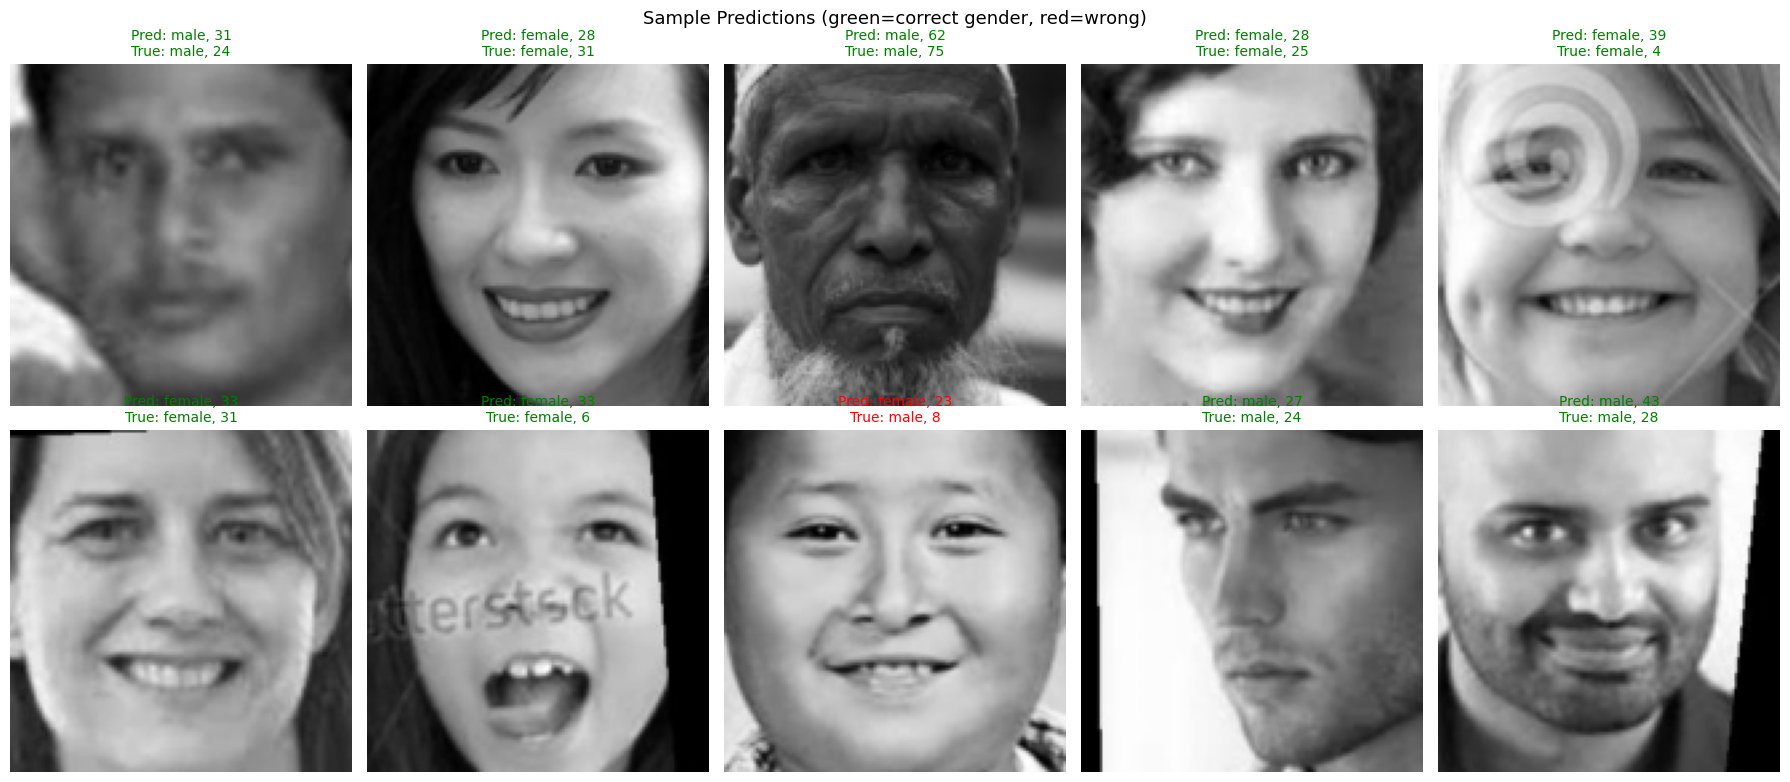

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

test_indices = random.sample(range(len(X_test)), 10)

for ax, idx in zip(axes.flatten(), test_indices):
    pred = best_model.predict(X_test[idx].reshape(1, 128, 128, 1), verbose=0)
    pred_gender = gender_dict[int(round(pred[0][0][0]))]
    pred_age    = int(round(pred[1][0][0]))

    true_gender = gender_dict[int(y_test_gender[idx])]
    true_age    = int(y_test_age[idx])

    ax.imshow(X_test[idx].reshape(128, 128), cmap='gray')
    color = 'green' if pred_gender == true_gender else 'red'
    ax.set_title(
        f"Pred: {pred_gender}, {pred_age}\n"
        f"True: {true_gender}, {true_age}",
        fontsize=10, color=color
    )
    ax.axis('off')

plt.suptitle('Sample Predictions (green=correct gender, red=wrong)', fontsize=13)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()

In [23]:
from IPython.display import FileLink

best_model.save('/kaggle/working/best_model.keras')
print("✓ Saved best_model.keras1")
print("\nDownload these files from output panel:")
print("  best_model.keras       ← your new model")
print("  training_curves.png")
print("  confusion_gender.png")
print("  sample_predictions.png")

FileLink('/kaggle/working/best_model.keras')

✓ Saved best_model.keras1

Download these files from output panel:
  best_model.keras       ← your new model
  training_curves.png
  confusion_gender.png
  sample_predictions.png


/kaggle/working/best_model.keras